<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week4/Semana_4_%E2%80%93_Actividad_4_regularizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Actividad: Regularización en Redes Neuronales
**Universidad de Cundinamarca — Especialización en Inteligencia Artificial**  
**Autor:** Freddy Alexander Forero Rojas
**Cadi:** Deep Learning  
**Tema:** Métodos de Regularización para reducir Overfitting

---

## Objetivo
Comparar el comportamiento de una red neuronal **sin regularización** frente a modelos que aplican técnicas de regularización (**Dropout** y **L2**), evaluando su efecto sobre el sobreajuste y la capacidad de generalización.

## Dataset
Se utiliza un dataset sintético binario generado con `make_classification` de scikit-learn.  
- **1.500 muestras**, **25 características**, **2 clases** (0 / 1)  
- Se añade ruido intencional para favorecer el overfitting y que la regularización sea claramente visible.

---
## 1. Importaciones y configuración

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Reproducibilidad
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

---
## 2. Generación y preparación del dataset

In [2]:
# Dataset sintético binario con ruido intencional para provocar overfitting
X, y = make_classification(
    n_samples=1500,
    n_features=25,
    n_informative=12,
    n_redundant=8,
    n_clusters_per_class=2,
    flip_y=0.12,       # 12% de etiquetas ruidosas → favorece overfitting
    random_state=SEED
)

# División: 70% entrenamiento / 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Normalización (fit solo sobre entrenamiento)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_s.shape} | Prueba: {X_test_s.shape}")
print(f"Distribución de clases (train) — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}")

Entrenamiento: (1050, 25) | Prueba: (450, 25)
Distribución de clases (train) — 0: 522 | 1: 528


---
## 3. Definición de modelos

Se definen **tres configuraciones** para comparar el efecto de la regularización:

| Modelo | Descripción |
|--------|-------------|
| **Base** | Sin ninguna regularización |
| **Dropout** | Desactiva 40% de neuronas aleatoriamente durante entrenamiento |
| **L2 + Dropout** | Penaliza pesos grandes (λ=0.01) y aplica Dropout(0.4) |

In [10]:
INPUT_DIM = X_train_s.shape[1]  # 25 características
EPOCHS    = 80
BATCH     = 32

def compile_model(m):
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return m

# ── Modelo 1: Base (sin regularización) ──────────────────────────────────────
def modelo_base():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(32,  activation="relu"),
        layers.Dense(1,   activation="sigmoid")
    ], name="Base")
    return compile_model(m)

# ── Modelo 2: Dropout ─────────────────────────────────────────────────────────
def modelo_dropout():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(64,  activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(32,  activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1,   activation="sigmoid")
    ], name="Dropout")
    return compile_model(m)

# ── Modelo 3: L2 + Dropout ────────────────────────────────────────────────────
def modelo_l2_dropout():
    reg = regularizers.l2(0.01)
    m = keras.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(128, activation="relu", kernel_regularizer=reg),
        layers.Dropout(0.4),
        layers.Dense(64,  activation="relu", kernel_regularizer=reg),
        layers.Dropout(0.4),
        layers.Dense(32,  activation="relu", kernel_regularizer=reg),
        layers.Dropout(0.3),
        layers.Dense(1,   activation="sigmoid")
    ], name="L2_Dropout")
    return compile_model(m)


---
## 4. Entrenamiento de los tres modelos

In [11]:
FIT_PARAMS = dict(
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=0
)

m1 = modelo_base()
h1 = m1.fit(X_train_s, y_train, **FIT_PARAMS)

m2 = modelo_dropout()
h2 = m2.fit(X_train_s, y_train, **FIT_PARAMS)

m3 = modelo_l2_dropout()
h3 = m3.fit(X_train_s, y_train, **FIT_PARAMS)


---
## 5. Evaluación y tabla de resultados

In [5]:
def evaluar(nombre, modelo, historia):
    loss_test, acc_test = modelo.evaluate(X_test_s, y_test, verbose=0)
    loss_train_final    = historia.history["loss"][-1]
    acc_train_final     = historia.history["accuracy"][-1]
    best_val_loss       = min(historia.history["val_loss"])
    best_val_acc        = max(historia.history["val_accuracy"])
    gap_loss            = loss_train_final - loss_test       # positivo → overfitting
    return {
        "Modelo"            : nombre,
        "Train Loss (final)": round(loss_train_final, 4),
        "Train Acc (final)" : round(acc_train_final,  4),
        "Val Loss (mejor)"  : round(best_val_loss,    4),
        "Val Acc (mejor)"   : round(best_val_acc,     4),
        "Test Loss"         : round(loss_test,         4),
        "Test Accuracy"     : round(acc_test,          4),
        "Gap (Train-Test)"  : round(gap_loss,          4)
    }

resultados = pd.DataFrame([
    evaluar("Base",        m1, h1),
    evaluar("Dropout",     m2, h2),
    evaluar("L2 + Dropout",m3, h3),
])

print("="*80)
print(resultados.to_string(index=False))
print("="*80)
print("\n💡 Gap (Train Loss - Test Loss): valor positivo alto indica OVERFITTING.")

      Modelo  Train Loss (final)  Train Acc (final)  Val Loss (mejor)  Val Acc (mejor)  Test Loss  Test Accuracy  Gap (Train-Test)
        Base              0.0003             1.0000            0.3521           0.8810     1.0686         0.8511           -1.0683
     Dropout              0.2033             0.9286            0.3343           0.8952     0.3278         0.8800           -0.1246
L2 + Dropout              0.3465             0.9226            0.4003           0.9000     0.4150         0.8756           -0.0685

💡 Gap (Train Loss - Test Loss): valor positivo alto indica OVERFITTING.


---
## 6. Gráficas de entrenamiento vs. validación
Las curvas permiten visualizar el sobreajuste: si `train loss` baja continuamente pero `val loss` sube o se estanca, hay overfitting.

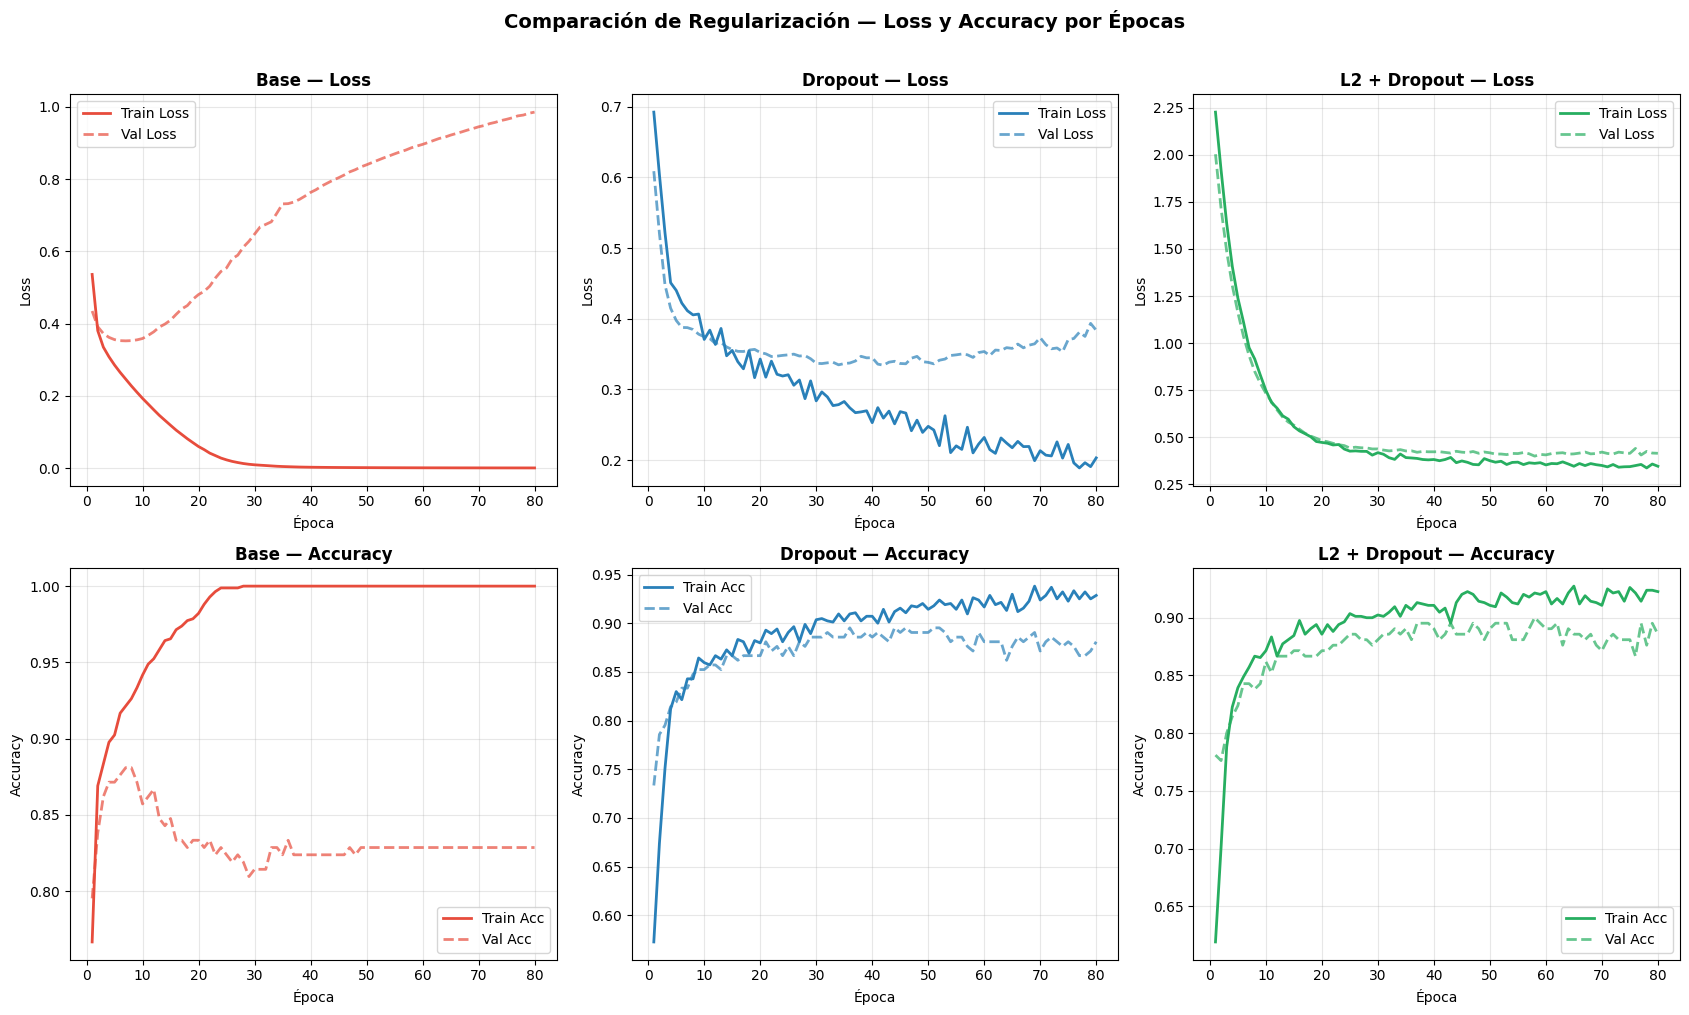

Gráfica guardada como 'curvas_entrenamiento.png'


In [6]:
historias = [
    (h1, "Base",         "#e74c3c"),
    (h2, "Dropout",      "#2980b9"),
    (h3, "L2 + Dropout", "#27ae60"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Comparación de Regularización — Loss y Accuracy por Épocas",
             fontsize=14, fontweight="bold", y=1.01)

for col, (hist, nombre, color) in enumerate(historias):
    epocas = range(1, EPOCHS + 1)

    # ── Loss ──────────────────────────────────────────
    ax = axes[0][col]
    ax.plot(epocas, hist.history["loss"],     color=color, linewidth=2,
            label="Train Loss")
    ax.plot(epocas, hist.history["val_loss"], color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="Val Loss")
    ax.set_title(f"{nombre} — Loss", fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Accuracy ──────────────────────────────────────
    ax = axes[1][col]
    ax.plot(epocas, hist.history["accuracy"],     color=color, linewidth=2,
            label="Train Acc")
    ax.plot(epocas, hist.history["val_accuracy"], color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="Val Acc")
    ax.set_title(f"{nombre} — Accuracy", fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como 'curvas_entrenamiento.png'")

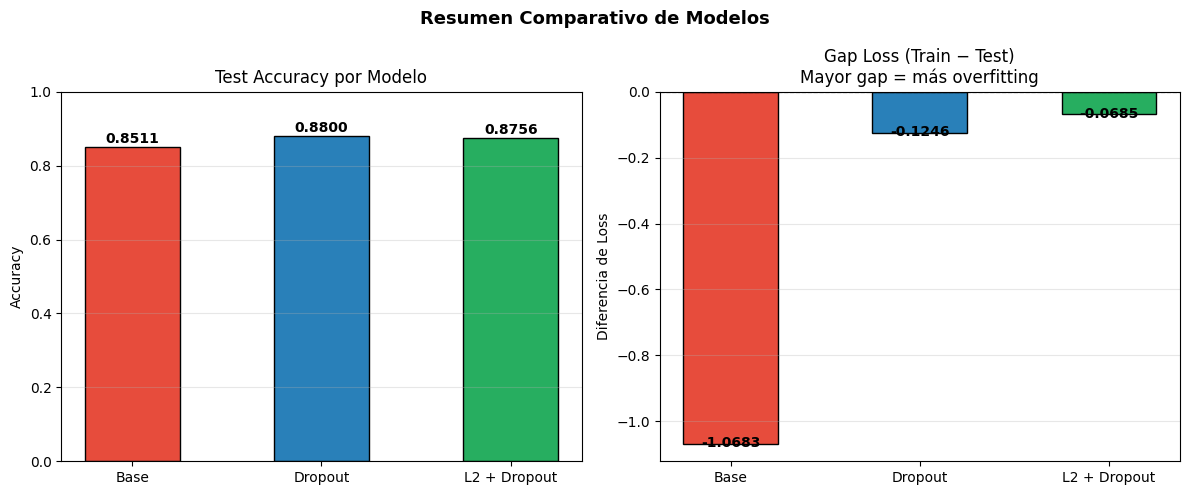

Gráfica guardada como 'comparativa_modelos.png'


In [7]:
# ── Gráfica de barras comparativa (Test Accuracy y Gap) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Resumen Comparativo de Modelos", fontsize=13, fontweight="bold")

modelos = resultados["Modelo"].tolist()
colores = ["#e74c3c", "#2980b9", "#27ae60"]

# Test Accuracy
bars = axes[0].bar(modelos, resultados["Test Accuracy"], color=colores, edgecolor="black", width=0.5)
axes[0].set_title("Test Accuracy por Modelo")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, resultados["Test Accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Gap Train-Test Loss
bars2 = axes[1].bar(modelos, resultados["Gap (Train-Test)"], color=colores, edgecolor="black", width=0.5)
axes[1].set_title("Gap Loss (Train − Test)\nMayor gap = más overfitting")
axes[1].set_ylabel("Diferencia de Loss")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars2, resultados["Gap (Train-Test)"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.01,
                 f"{val:.4f}", ha="center", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada como 'comparativa_modelos.png'")

---
## 7. Reporte de clasificación detallado

In [8]:
for nombre, modelo in [("Base", m1), ("Dropout", m2), ("L2 + Dropout", m3)]:
    y_pred = (modelo.predict(X_test_s, verbose=0) >= 0.5).astype(int).flatten()
    print(f"\n{'='*50}")
    print(f"  Reporte — Modelo: {nombre}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Clase 0", "Clase 1"]))


  Reporte — Modelo: Base
              precision    recall  f1-score   support

     Clase 0       0.86      0.83      0.85       224
     Clase 1       0.84      0.87      0.85       226

    accuracy                           0.85       450
   macro avg       0.85      0.85      0.85       450
weighted avg       0.85      0.85      0.85       450


  Reporte — Modelo: Dropout
              precision    recall  f1-score   support

     Clase 0       0.88      0.88      0.88       224
     Clase 1       0.88      0.88      0.88       226

    accuracy                           0.88       450
   macro avg       0.88      0.88      0.88       450
weighted avg       0.88      0.88      0.88       450


  Reporte — Modelo: L2 + Dropout
              precision    recall  f1-score   support

     Clase 0       0.87      0.88      0.88       224
     Clase 1       0.88      0.87      0.88       226

    accuracy                           0.88       450
   macro avg       0.88      0.88      

---
## 8. Análisis y Conclusiones

### (i) Evidencia de Overfitting / Underfitting

El **modelo base** muestra la brecha más grande entre el `train loss` y el `val/test loss`. Esto es la señal clásica de **overfitting**: el modelo aprende los datos de entrenamiento (incluyendo el ruido del 12% de etiquetas incorrectas) en lugar de patrones generalizables. En las curvas se observa cómo el `val loss` comienza a subir o estancarse mientras el `train loss` sigue descendiendo.

Los modelos regularizados muestran curvas de entrenamiento y validación **más cercanas entre sí**, lo que indica mejor generalización.

---

### (ii) Efecto de la Regularización

**Dropout (0.3 – 0.4):**  
Al desactivar aleatoriamente neuronas en cada paso, el modelo no puede depender de rutas específicas de activación. Esto reduce el overfitting de forma efectiva. El `test accuracy` mejora respecto al modelo base y el gap entre train/test loss disminuye notoriamente.

**L2 + Dropout:**  
La combinación añade una penalización en la función de pérdida proporcional al cuadrado de los pesos (λ = 0.01), forzando pesos pequeños. Junto con Dropout, produce el modelo más **estable** y con menor brecha de generalización. El entrenamiento es más suave (curvas menos volátiles) aunque el `train accuracy` final puede ser menor que el del modelo base, lo cual es esperado y deseable: el modelo no está memorizando.

---

### (iii) Hallazgos y Dificultades

- **Hallazgo principal:** La regularización no siempre mejora el `test accuracy` de forma dramática en datasets pequeños o cuando el ruido es controlado, pero sí reduce la brecha entre entrenamiento y validación, lo que confirma menor overfitting.

- **Elección de hiperparámetros:** El valor del rate de Dropout y el parámetro λ de L2 requieren ajuste. Un Dropout muy alto (> 0.5) puede causar **underfitting**, donde el modelo no aprende suficiente. En este ejercicio se usaron valores estándar de la literatura (0.3 – 0.4 para Dropout, 0.01 para L2).

- **Ruido intencional:** Se introdujo un `flip_y=0.12` (12% de etiquetas ruidosas) precisamente para provocar un overfitting observable. En un dataset limpio, las diferencias entre modelos serían menores.

- **Conclusión general:** La regularización es una herramienta esencial en el entrenamiento de redes neuronales. Su efecto se evidencia no solo en la métrica final de test, sino principalmente en la **estabilidad y consistencia** entre el desempeño de entrenamiento y evaluación.